In [1]:
import json
import sys
from pathlib import Path
import numpy as np

# Splice class labels (must match SpliceSiteAnnotation)
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
ORGANISM_NAMES = {0: "human", 1: "mouse"}

# Visual labels and colors matching predict_splicing_windows.py
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

# Source-flag constants (for by-source AUPRC analysis)
SRC_INTERSECT  = 0  # in both GTF and usage
SRC_GTF_ONLY   = 1  # in GTF only
SRC_USAGE_ONLY = 2  # in usage only
SRC_BACKGROUND = 3  # unannotated

SOURCE_LABELS = {
    SRC_INTERSECT:  "intersect",
    SRC_GTF_ONLY:   "gtf_only",
    SRC_USAGE_ONLY: "usage_only",
    SRC_BACKGROUND: "background",
}

### Helper functions

In [2]:
# Source-annotation helpers

def build_usage_position_set(usage_parquet: str) -> set[tuple[str, int]]:
    """Return set of (chrom, 0-based position) present in usage.parquet."""
    import pandas as pd
    usage_json = Path(usage_parquet).with_suffix(".json")
    with open(usage_json) as f:
        meta = json.load(f)
    none_class = meta["class_labels"].get("None", 4)
    df = pd.read_parquet(usage_parquet)
    df = df[df["Label"] != none_class]
    df["Chromosome"] = df["Chromosome"].astype(str)
    df["Position"]   = df["Position"].astype(int)
    return set(zip(df["Chromosome"], df["Position"]))


def build_gtf_position_set(gtf_parquet: str) -> set[tuple[str, int]]:
    """Return set of (chrom, 0-based position) present in a GTF-derived parquet."""
    import pandas as pd
    df = pd.read_parquet(gtf_parquet)
    df["Chromosome"] = df["Chromosome"].astype(str)
    df["Position"]   = df["Position"].astype(int)
    return set(zip(df["Chromosome"], df["Position"]))


def build_source_arrays(
    annotation_parquet: str,
    gtf_positions: set[tuple[str, int]],
    usage_positions: set[tuple[str, int]],
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """Return per-chrom (sorted_positions, src_flags) for source tagging."""
    import pandas as pd
    df = pd.read_parquet(annotation_parquet)
    df["Chromosome"] = df["Chromosome"].astype(str)
    df["Position"]   = df["Position"].astype(int)
    result: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for chrom, grp in df.groupby("Chromosome"):
        grp = grp.sort_values("Position")
        pos = grp["Position"].to_numpy(dtype=np.int64)
        src = np.empty(len(pos), dtype=np.int8)
        for i, p in enumerate(pos):
            key = (str(chrom), int(p))
            in_gtf   = key in gtf_positions
            in_usage = key in usage_positions
            if in_gtf and in_usage:
                src[i] = SRC_INTERSECT
            elif in_gtf:
                src[i] = SRC_GTF_ONLY
            else:
                src[i] = SRC_USAGE_ONLY
        result[str(chrom)] = (pos, src)
    return result


def build_gene_overlap_mask(
    bed_file: str,
    gene_intervals: dict[str, np.ndarray],
    sequence_length: int = 131_072,
) -> np.ndarray:
    """Build a boolean mask over all per-position predictions.

    Returns a 1-D boolean array of length ``n_windows * sequence_length``
    where ``True`` means the position falls within a gene interval.
    """
    half = sequence_length // 2

    # Chromosome alias map (handle chr-prefix mismatches)
    alias: dict[str, str] = {}
    for chrom in gene_intervals:
        alias[chrom] = chrom
        if chrom.startswith("chr"):
            alias[chrom[3:]] = chrom
        else:
            alias["chr" + chrom] = chrom

    masks: list[np.ndarray] = []
    with open(bed_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            chrom_raw = parts[0]
            chrom = alias.get(chrom_raw, chrom_raw)
            center = (int(parts[1]) + int(parts[2])) // 2
            win_start = center - half

            win_mask = np.zeros(sequence_length, dtype=bool)
            intervals = gene_intervals.get(chrom)
            if intervals is not None:
                starts = intervals[:, 0]
                ends = intervals[:, 1]
                lo = int(np.searchsorted(ends, win_start, side="right"))
                hi = int(np.searchsorted(starts, win_start + sequence_length, side="left"))
                for gs, ge in zip(starts[lo:hi], ends[lo:hi]):
                    rel_start = max(0, int(gs) - win_start)
                    rel_end = min(sequence_length, int(ge) - win_start)
                    if rel_start < rel_end:
                        win_mask[rel_start:rel_end] = True
            masks.append(win_mask)

    return np.concatenate(masks)


def build_gene_intervals(gene_annotation_parquet: str) -> dict[str, np.ndarray]:
    """Build merged gene intervals per chromosome from a gene annotation parquet.

    Reads transcript (or all) features and merges overlapping intervals per
    chromosome.  Returns ``{chrom: array of shape (N, 2)}`` where each row is
    a ``[start, end)`` 0-based half-open interval (sorted, non-overlapping).
    """
    import pandas as pd

    df = pd.read_parquet(
        gene_annotation_parquet,
        columns=["Chromosome", "Feature", "Start", "End"],
    )
    tx = df[df["Feature"] == "transcript"][["Chromosome", "Start", "End"]]
    if tx.empty:
        # Fallback: use all rows (some annotations lack an explicit transcript feature)
        tx = df[["Chromosome", "Start", "End"]].drop_duplicates()
    tx = tx.copy()
    tx["Chromosome"] = tx["Chromosome"].astype(str)

    result: dict[str, np.ndarray] = {}
    for chrom, grp in tx.groupby("Chromosome"):
        starts = grp["Start"].values.astype(np.int64)
        ends = grp["End"].values.astype(np.int64)
        order = np.argsort(starts)
        starts = starts[order]
        ends = ends[order]

        # Merge overlapping / adjacent intervals
        ms = [int(starts[0])]
        me = [int(ends[0])]
        for i in range(1, len(starts)):
            if starts[i] <= me[-1]:
                me[-1] = max(me[-1], int(ends[i]))
            else:
                ms.append(int(starts[i]))
                me.append(int(ends[i]))
        result[str(chrom)] = np.column_stack([ms, me])
    return result



In [3]:
# Load predictions

def load_predictions(
    out_dir: Path,
    org_name: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray | None, dict]:
    """Load predictions saved by save_predictions."""
    npz_path = out_dir / f"predictions_{org_name}.npz"
    if not npz_path.exists():
        sys.exit(f"Prediction file not found: {npz_path}  (run without --plot-only first)")
    data       = np.load(npz_path)
    cls_probs  = data["cls_probs"]
    cls_labels = data["cls_labels"]
    src_tags   = data["src_tags"] if "src_tags" in data else None

    usage_path = out_dir / f"usage_{org_name}.json"
    usage_per_cond: dict = {}
    if usage_path.exists():
        with open(usage_path) as f:
            usage_per_cond = {int(k): v for k, v in json.load(f).items()}
    print(f"  Loaded predictions from {npz_path}")
    return cls_probs, cls_labels, src_tags, usage_per_cond


***

### Loaded predictions for a region

Load predictions

In [81]:
all_results: dict[str, dict] = {}

org_name = "human"
out_dir = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/predictions"
out_dir = Path(out_dir)
cls_probs, cls_labels, src_tags, usage_per_cond = load_predictions(out_dir, org_name)

  Loaded predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/predictions/predictions_human.npz


Map splice sites to genomic coordinates

In [82]:
import numpy as np
import pandas as pd

# Read the BED file to recover window coordinates (same order as dataset)
seq_len = 131_072
half = seq_len // 2
windows = []
bed_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/predictions/filtered_bed_human.bed"
with open(bed_fn) as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) < 3 or line.startswith("#"):
            continue
        chrom = parts[0]
        center = (int(parts[1]) + int(parts[2])) // 2
        windows.append((chrom, center - half, center + half))

In [86]:
# Subset windows regions overlapping genes (for gene-only evaluation)
gene_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/gene_annotation.parquet"
gene_int = pd.read_parquet(gene_fn)
gene_intervals = build_gene_intervals(gene_fn)
gene_mask = build_gene_overlap_mask(
    bed_file=bed_fn,
    gene_intervals=gene_intervals,
    sequence_length=seq_len,
)
n_in_gene = int(gene_mask.sum())
n_total_pos = len(gene_mask)
print(
    f"[{org_name}] Position-level gene filter: {n_in_gene:,} / "
    f"{n_total_pos:,} positions in genes ({100*n_in_gene/max(n_total_pos,1):.1f}%)"
)

[human] Position-level gene filter: 479,920,664 / 718,536,704 positions in genes (66.8%)


In [87]:
cls_probs = cls_probs[gene_mask]
cls_labels = cls_labels[gene_mask]
if src_tags is not None:
    src_tags = src_tags[gene_mask]

#### Get predictions for a position at a specific genomic coordinate.

In [18]:
window_idx = 0
position_in_window = 109239  # 0-based offset within the 131kb window

chrom, win_start, win_end = windows[window_idx]
genomic_pos = win_start + position_in_window
probs = cls_probs_reshape[window_idx, position_in_window]  # (5,) class probs

print(f"{chrom}:{genomic_pos}  probs={probs}")

1:121252132  probs=[0.01903681 0.02192645 0.18247774 0.16488005 0.611679  ]


#### Get predictions for a genomic region

In [74]:
window_idx = 0

chrom, win_start, win_end = windows[window_idx]

genomic_position_start = 121_252_000
genomic_position_end = 121_253_700

window_position_start = genomic_position_start - win_start
window_position_end = genomic_position_end - win_start

# Get predicted probabilities for this region
probs = cls_probs_reshape[window_idx, window_position_start : window_position_end]
print(f"Predicted probabilities shape: {probs.shape}")

# Get true labels for the same region
true_labels = cls_labels_reshape[window_idx, window_position_start : window_position_end]
print(f"True labels shape: {true_labels.shape}")

Predicted probabilities shape: (1700, 5)
True labels shape: (1700,)


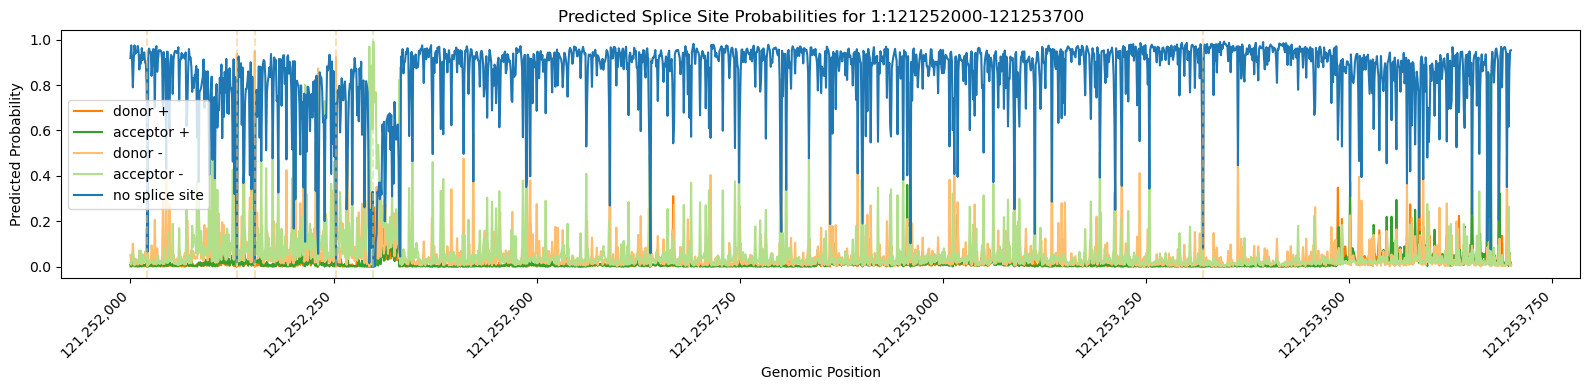

In [75]:
from matplotlib.ticker import FuncFormatter

# Plot probabilities for each class across the region
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))  # fixes: ax was undefined

x = np.arange(genomic_position_start, genomic_position_end)
for class_idx in range(5):
    ax.plot(
        x,
        probs[:, class_idx],
        label=CLASS_LABELS[class_idx],
        color=CLASS_COLORS[class_idx],
    )

ax.set_xlabel("Genomic Position")
ax.set_ylabel("Predicted Probability")
ax.set_title(f"Predicted Splice Site Probabilities for {chrom}:{genomic_position_start}-{genomic_position_end}")

# Add vertical lines for true splice sites
for pos, label in zip(x, true_labels):
    if label != BACKGROUND_CLASS:
        ax.axvline(pos, color=CLASS_COLORS[label], linestyle="--", alpha=0.5)

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend()
plt.tight_layout()
plt.show()

Calculate and plot AUPRC for the region

AUPRC for class 'donor -':
AUPRC for class 'acceptor -':


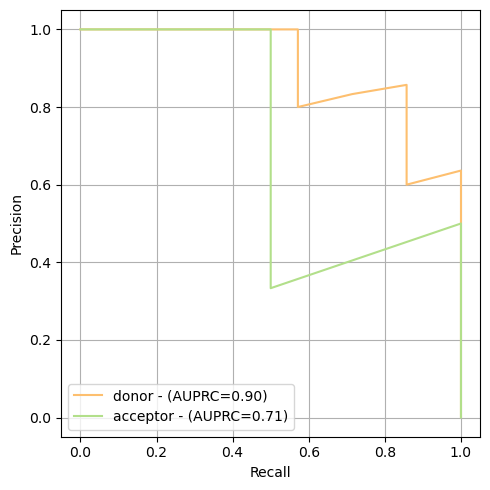

In [73]:
from sklearn.metrics import auc, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
y_true = true_labels
auprc_dict = {}
for class_idx, class_name in enumerate(CLASS_LABELS.values()):
    if class_idx == BACKGROUND_CLASS:
        continue  # skip background class for AUPRC calculation
    if np.sum(y_true == class_idx) == 0:
        continue # skip if no true positives for this class
    y_scores = probs[:, class_idx]
    y_labels = (y_true == class_idx).astype(int)
    precision, recall, thresholds = precision_recall_curve(y_labels, y_scores)
    print(f"AUPRC for class '{class_name}':")
    pr_auc = auc(recall, precision)
    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AUPRC={pr_auc:.2f})",
        color=CLASS_COLORS[class_idx],
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid()
plt.tight_layout()
plt.show()

#### Get predictions for multiple genomic regions

In [102]:
y_true = cls_labels[0:100_000]
probs = cls_probs[0:100_000, :]

AUPRC for class 'donor +':
AUPRC for class 'acceptor +':
AUPRC for class 'donor -':
AUPRC for class 'acceptor -':


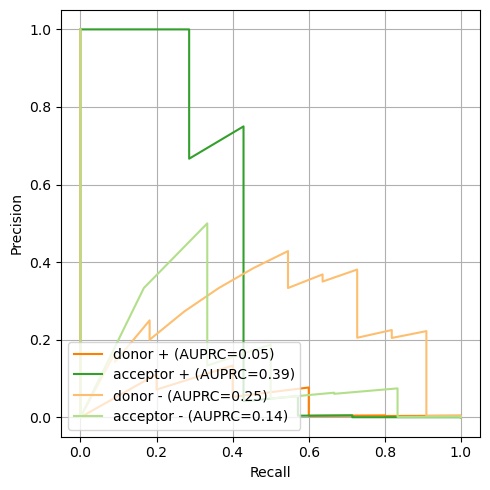

In [103]:
from sklearn.metrics import auc, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

auprc_dict = {}
for class_idx, class_name in enumerate(CLASS_LABELS.values()):
    if class_idx == BACKGROUND_CLASS:
        continue  # skip background class for AUPRC calculation
    if np.sum(y_true == class_idx) == 0:
        continue # skip if no true positives for this class
    y_scores = probs[:, class_idx]
    y_labels = (y_true == class_idx).astype(int)
    precision, recall, thresholds = precision_recall_curve(y_labels, y_scores)
    print(f"AUPRC for class '{class_name}':")
    pr_auc = auc(recall, precision)
    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AUPRC={pr_auc:.2f})",
        color=CLASS_COLORS[class_idx],
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid()
plt.tight_layout()
plt.show()

***

### Splice sites overlap

Count splice sites by source

In [ ]:
# Build per-source annotation index
source_arrays = None
gtf_path = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites_gtf.parquet"
usage_path = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/usage.parquet"
annotation_path = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/Homo_sapiens/splice_sites.parquet"

gtf_positions   = build_gtf_position_set(gtf_path)
usage_positions = build_usage_position_set(usage_path)
source_arrays   = build_source_arrays(
    annotation_path, gtf_positions, usage_positions
)

n_i = sum((s == SRC_INTERSECT).sum()  for _, s in source_arrays.values())
n_g = sum((s == SRC_GTF_ONLY).sum()   for _, s in source_arrays.values())
n_u = sum((s == SRC_USAGE_ONLY).sum() for _, s in source_arrays.values())
print(f"  Intersect: {n_i:,}  GTF-only: {n_g:,}  Usage-only: {n_u:,}")

***

### Splice site classification

In [9]:
def compute_classification_metrics(probs: np.ndarray, labels: np.ndarray) -> dict:
    try:
        from sklearn.metrics import average_precision_score
    except ImportError:
        sys.exit("scikit-learn is required. Install: pip install scikit-learn")

    y_binary = (labels != BACKGROUND_CLASS).astype(np.int32)
    s_binary = 1.0 - probs[:, BACKGROUND_CLASS]
    binary_auprc = float(average_precision_score(y_binary, s_binary))
    pos_rate = float(y_binary.mean())

    per_class_auprc: dict[str, float] = {}
    per_class_n: dict[str, int] = {}
    for c, name in enumerate(SPLICE_CLASS_NAMES):
        y_c = (labels == c).astype(np.int32)
        n_pos = int(y_c.sum())
        if n_pos == 0:
            continue
        per_class_auprc[name] = float(average_precision_score(y_c, probs[:, c]))
        per_class_n[name] = n_pos

    mean_per_class = (
        float(np.mean(list(per_class_auprc.values()))) if per_class_auprc else float("nan")
    )

    return {
        "binary_auprc": binary_auprc,
        "positive_rate": pos_rate,
        "per_class_auprc": per_class_auprc,
        "per_class_n_positives": per_class_n,
        "mean_splice_class_auprc": mean_per_class,
        "n_positions": int(len(labels)),
    }

In [10]:
y_binary = (cls_labels != BACKGROUND_CLASS).astype(np.int32)
s_binary = 1.0 - cls_probs[:, BACKGROUND_CLASS]

In [ ]:
y_binary

In [ ]:
s_binary

Binary AUPRC for any splice site prediction vs background (not-a-splice sites)

In [ ]:
from sklearn.metrics import average_precision_score
binary_auprc = float(average_precision_score(y_binary, s_binary))
print(binary_auprc)
pos_rate = float(y_binary.mean())
print(pos_rate)

In [ ]:
src_tags

In [35]:
# Dictionary for results
results: dict[str, dict] = {}

# Use true labels to identify all background sites
true_bg_mask = cls_labels == BACKGROUND_CLASS

# for src_val in (SRC_INTERSECT, SRC_GTF_ONLY, SRC_USAGE_ONLY):
src_val = SRC_INTERSECT

src_name = SOURCE_LABELS[src_val]
ann_mask = src_tags == src_val

# Include positives from this source and all background sites (true negatives)
mask = ann_mask | true_bg_mask

In [ ]:
# y_bin: 1 for this source, 0 for background
y_bin = ann_mask[mask].astype(np.int32)
y_bin

In [ ]:
s_bin = 1.0 - cls_probs[mask, BACKGROUND_CLASS]
s_bin

In [ ]:
binary_ap = (
    float(average_precision_score(y_bin, s_bin))
    if y_bin.sum() > 0 else float("nan")
)
print(binary_ap)

In [ ]:
# Per-class AUPRC among annotated sites of this source only
ann_probs  = cls_probs[ann_mask]
bg_probs   = cls_probs[true_bg_mask]
ann_labels = cls_labels[ann_mask]
per_class: dict[str, float] = {}
per_class_n: dict[str, int] = {}
for c, name in enumerate(SPLICE_CLASS_NAMES):
    y_c_ann = (ann_labels == c).astype(np.int32)
    if y_c_ann.sum() == 0:
        continue
    # Combine annotated sites of this source with all background sites
    y_c = np.concatenate([y_c_ann, np.zeros(len(bg_probs), dtype=np.int32)])
    s_c = np.concatenate([ann_probs[:, c], bg_probs[:, c]])
    per_class[name]   = float(average_precision_score(y_c, s_c))
    per_class_n[name] = int(y_c_ann.sum())

In [ ]:
per_class

In [ ]:
mean_pc = float(np.mean(list(per_class.values()))) if per_class else float("nan")
mean_pc

***

### Splice site usage

In [ ]:
def compute_usage_metrics(usage_per_cond: dict) -> dict:
    try:
        from scipy.stats import pearsonr
    except ImportError:
        sys.exit("scipy is required. Install: pip install scipy")

    rs: list[float] = []
    n_obs_total = 0

    for data in usage_per_cond.values():
        pred = np.array(data["pred"])
        true = np.array(data["true"])
        n_obs_total += len(pred)
        if len(pred) < 2 or pred.std() < 1e-8 or true.std() < 1e-8:
            continue
        r, _ = pearsonr(pred, true)
        rs.append(float(r))

    if not rs:
        return {
            "usage_mean_pearson_r": float("nan"),
            "usage_median_pearson_r": float("nan"),
            "usage_n_conditions_evaluated": 0,
            "usage_n_conditions_total": len(usage_per_cond),
            "usage_n_observations": n_obs_total,
        }

    return {
        "usage_mean_pearson_r": float(np.mean(rs)),
        "usage_median_pearson_r": float(np.median(rs)),
        "usage_n_conditions_evaluated": len(rs),
        "usage_n_conditions_total": len(usage_per_cond),
        "usage_n_observations": n_obs_total,
    }

In [49]:
usage_per_cond

{0: {'pred': [0.9373390674591064,
   0.09045571833848953,
   0.9470953345298767,
   0.10045608878135681,
   0.8816798329353333,
   0.8929262161254883,
   0.8866878747940063,
   0.9221931099891663,
   0.2214781641960144,
   0.7669147849082947,
   0.5568626523017883,
   0.91640704870224,
   0.38132235407829285,
   0.8470182418823242,
   0.009230360388755798,
   0.0109957130625844,
   0.011931379325687885,
   0.8358849883079529,
   0.8952655792236328,
   0.8994783759117126,
   0.7493746876716614,
   0.3704034686088562,
   0.4805378019809723,
   0.8357473611831665,
   0.8713830709457397,
   0.8328360915184021,
   0.2949223220348358,
   0.29586780071258545,
   0.9007673859596252,
   0.7752050757408142,
   0.8941388130187988,
   0.04983227327466011,
   0.9273399710655212,
   0.9253323674201965,
   0.7827556133270264,
   0.9472811222076416,
   0.8664442896842957,
   0.8048247694969177,
   0.8980454206466675,
   0.9232190251350403,
   0.06502209603786469,
   0.9344936013221741,
   0.0837910473

In [50]:
from scipy.stats import pearsonr

rs: list[float] = []
n_obs_total = 0

for data in usage_per_cond.values():
    pred = np.array(data["pred"])
    true = np.array(data["true"])
    n_obs_total += len(pred)
    if len(pred) < 2 or pred.std() < 1e-8 or true.std() < 1e-8:
        continue
    r, _ = pearsonr(pred, true)
    rs.append(float(r))


Text(0.5, 1.0, 'Distribution of Pearson r across conditions')

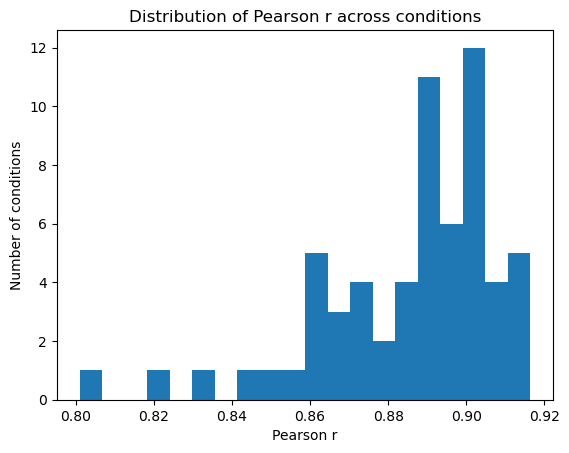

In [53]:
# plot histogram of rs
import matplotlib.pyplot as plt
plt.hist(rs, bins=20)
plt.xlabel("Pearson r")
plt.ylabel("Number of conditions")
plt.title("Distribution of Pearson r across conditions")

In [51]:
mean_pearsonr = float(np.mean(rs)) if rs else float("nan")
mean_pearsonr

0.8859901196788393

***

### Splice site usage difference

For each site, calculate delta from the mean across conditions

In [ ]:
usage_per_cond.keys()

mean_usage_per_cond

dict_keys([0, 3, 5, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 59, 60, 61, 6, 53, 1, 2, 4, 7, 9, 35, 46, 58])